#  앙상블 Part 2 — Boosting & Gradient Boosting

---

### 목표
- Bagging(Random Forest)이 “**분산(Variance)**”을 줄이는 기법이었다면,
  이번엔 “**편향(Bias)**”을 줄이는 **Boosting**을 배운다.
- Boosting → AdaBoost → Gradient Boosting → XGBoost/LightGBM까지
  한 줄로 이해할 수 있는 **직관 + 코드 + 시각화**를 만든다.

In [1]:
# 팁
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

px.defaults.template = "plotly_dark"
px.defaults.width = 800
px.defaults.height = 450

SEED = 42
np.random.seed(SEED)


## Bagging vs Boosting 복습

---

### 개념 정리

| 구분 | **Bagging (배깅)** | **Boosting (부스팅)**                   |
|------|--------------------|--------------------------------------|
| 학습 방식 | **병렬(Parallel)** | **순차(Sequential)**                   |
| 목표 | **Variance 감소 (안정성↑)** | **Bias 감소 (정확성↑)(단, Variance ↑ 가능)** |
| 데이터 샘플링 | Bootstrap (복원추출) | Residual(잔차) 기반 반복 순차 학습             |
| 모델 간 관계 | 독립(Independent) | 종속(Dependent, 앞 모델 잔차(오차) 반영)        |
| 대표 알고리즘 | Random Forest | AdaBoost, Gradient Boosting          |

### 정리
- **Bagging → 흔들림(Variance)을 줄이는 앙상블 (안정성 향상)**
- **Boosting → 오차(Bias)를 줄이는 앙상블 (정확성 향상)**


| **구분**       | **초점**            | **비유**       | **대표 알고리즘**   |
| ------------ | ----------------- | ------------ | ------------- |
| **Bagging**  | Variance ↓ (안정성↑) | 여러 명이 동시에 팀플 | Random Forest |
| **Boosting** | Bias ↓ (정확성↑)     | 오답노트로 단계적 보완 | AdaBoost, GBM |


## 회귀 트리(Regression Tree) — 분류만 하는 게 아니다!

5회차에서 배운 결정 트리는 **분류 트리(Classification Tree)**였습니다.  
하지만 결정 트리에는 **회귀 트리(Regression Tree)**도 있습니다!

| 구분 | 분류 트리 (Classification Tree) | 회귀 트리 (Regression Tree) |
|------|------|------|
| 목적 | 범주(클래스) 예측 | 연속 값(숫자) 예측 |
| 리프 노드 출력 | 다수결 클래스 | 평균값 |
| 불순도 기준 | Gini / Entropy | MSE (평균제곱오차) |
| sklearn | `DecisionTreeClassifier` | `DecisionTreeRegressor` |
| 예시 | 품종 분류, 스팸 여부 | 집값 예측, 매출 예측 |

> **왜 지금 이걸 배울까?**  
> Gradient Boosting은 **잔차(residual = 실제값 − 예측값)**를 학습함
> 잔차는 **연속 값(숫자)**이므로, 부스팅의 각 스텝은 사실상 **회귀 트리**를 사용함
> 즉, 부스팅을 제대로 이해하려면 회귀 트리를 먼저 알아야 함

![트리는 숫자를 계산할 수 있다 — 회귀 트리의 원리](regression_tree_myth.png)

In [2]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.metrics import mean_squared_error, r2_score
import graphviz

np.random.seed(42)
X_reg = np.sort(np.random.rand(80, 1) * 10, axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, 80)

reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_reg, y_reg)

print(f"R² Score : {r2_score(y_reg, reg_tree.predict(X_reg)):.3f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_reg, reg_tree.predict(X_reg))):.3f}")

R² Score : 0.864
RMSE     : 0.256


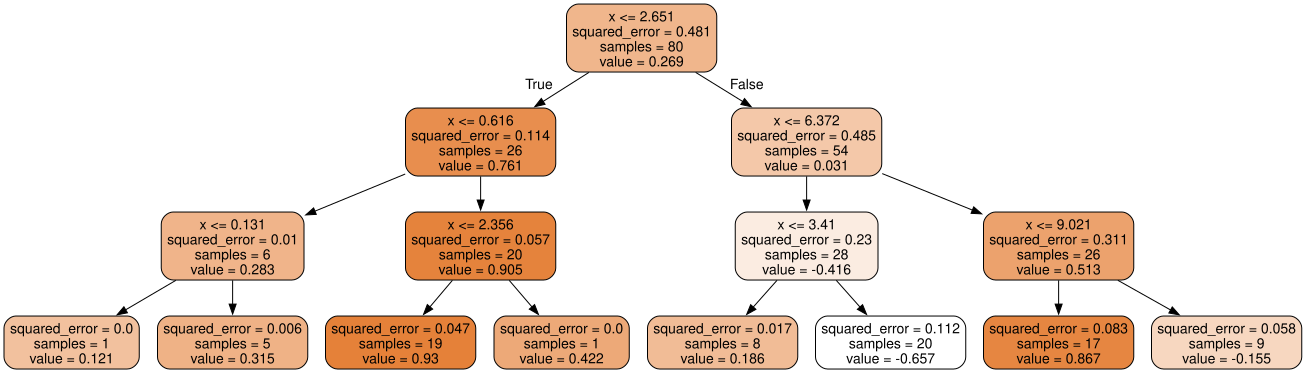

In [3]:
dot_reg = export_graphviz(
    reg_tree,
    out_file=None,
    feature_names=["x"],
    filled=True,
    rounded=True,
    impurity=True
)
graphviz.Source(dot_reg)

### 회귀 트리 시각화 해석

위 트리를 읽는 법:
- **mse**: 해당 노드의 평균제곱오차 (불순도 역할 — 작을수록 좋음)
- **samples**: 노드에 도달한 데이터 수
- **value**: 해당 노드의 **예측값** (= 리프에 속하는 데이터의 평균)
- 분류 트리와 달리 클래스가 아니라 **숫자(연속값)**를 예측합니다!

> 분류 트리: 리프 노드 → **다수결 클래스**  
> 회귀 트리: 리프 노드 → **평균값** (연속 값)

In [4]:
import plotly.graph_objects as go

X_plot = np.linspace(0, 10, 500).reshape(-1, 1)
y_plot = reg_tree.predict(X_plot)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X_reg.ravel(), y=y_reg,
    mode="markers", name="실제 데이터 (sin + 노이즈)",
    marker=dict(size=6, color="#00BFFF")
))
fig.add_trace(go.Scatter(
    x=X_plot.ravel(), y=y_plot,
    mode="lines", name="회귀 트리 예측 (depth=3)",
    line=dict(color="#FF6347", width=3)
))
fig.add_trace(go.Scatter(
    x=X_plot.ravel(), y=np.sin(X_plot).ravel(),
    mode="lines", name="원래 함수 sin(x)",
    line=dict(color="gray", width=1, dash="dash")
))
fig.update_layout(
    title="회귀 트리(DecisionTreeRegressor) — 예측 결과",
    xaxis_title="x",
    yaxis_title="y",
    template="plotly_dark",
    width=800, height=450
)
fig.show()

# 계단 모양 → 회귀 트리는 구간별 평균값을 예측
# depth가 깊으면 더 세밀하게 쪼개지만 과적합 위험 증가

### 핵심 정리 — 회귀 트리 → 부스팅 연결

| | 분류 트리 | 회귀 트리 |
|---|---|---|
| 출력 | 클래스 라벨 | 연속 값 (숫자) |
| 리프 노드 | 다수결 → 클래스 | 평균값 → 숫자 |
| 불순도 | Gini / Entropy | MSE |
| sklearn | `DecisionTreeClassifier` | `DecisionTreeRegressor` |

> **기억**
>
> 이어서 배울 **Gradient Boosting은 각 스텝에서 회귀 트리를 사용**.
> "잔차(실제 − 예측)"라는 **숫자**를 예측해야 함

---

## Boosting 아이디어 — 순차적 학습의 시작


### 핵심 아이디어
> 여러 개의 약한 모델이 순차적으로 학습**하면서,
> 앞 모델이 틀린 부분(오류, 잔차)**을 다음 모델이 보완**한다.

**핵심 로직**
1. 첫 번째 모델 → 데이터를 학습해 예측
2. 오차(Residual = 실제 - 예측) 계산
3. 다음 모델 → 이 오차(잔차)를 예측하도록 학습
4. 최종 예측 = 이전 예측 + 새로운 보정(오차 보정)


## AdaBoost — Adaptive Boosting

- 정의
    - AdaBoost는 틀린 샘플의 가중치를 올려, 다음 약한 모델(weak learner)이 어려운 샘플에 더 집중하게 만드는 순차형(Sequential) 앙상

![AdaBoost: '틀린 문제 다시 풀기' 전략](adaboost_strategy.png)

- 학습 방법:
    1. 처음엔 모든 샘플 가중치가 동일 (w = 1/N)
	2. 틀린 샘플의 가중치 ↑ → 다음 모델이 그 샘플을 더 중요하게 학습
	3. 각 모델의 성능에 따라 모델 가중치(α_t) 부여
	4. 최종 예측 = 모델별 예측 × 가중치(α_t)의 합

![AdaBoost 출발점: 가중치 증가](adaboost_weight_increase.png)

##  참고
- 약한 학습기(weak learner): 보통 깊이 1 의사결정나무
- 핵심 하이퍼파라미터
    - n_estimators: 약한 모델의 개수 (너무 많으면 과적합 위험)
    - learning_rate: 한 단계 보정 강도(보폭). 작을수록 천천히, 안정적으로 → 더 많은 스텝 필요(시간이 더 걸림)

In [5]:
import numpy as np, pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

X, y = load_wine(return_X_y=True)
target_names = load_wine().target_names
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# 약한 학습기: 깊이 1(Decision Stump)
stump = DecisionTreeClassifier(max_depth=1, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### n_estimators 변화에 따른 성능 (learning_rate=0.5 고정)
- 왜? 스텝 수가 늘수록 점진적으로 좋아지다가 과적합될 수 있기 때문
- Test Accuracy + CV 평균을 함께 봄(운빨 대비)

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import plotly.graph_objects as go
import pandas as pd

# 약한 학습기: 깊이 1 의사결정나무
stump = DecisionTreeClassifier(max_depth=1, random_state=42)

n_list = [10, 30, 50, 100, 200, 300]
rows = []

for n in n_list:
    ada = AdaBoostClassifier(
        estimator=stump,
        n_estimators=n,
        learning_rate=0.5,
        random_state=42,
    )
    ada.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, ada.predict(X_test))
    cv_mean = cross_val_score(ada, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()
    rows.append((n, test_acc, cv_mean))

df_curve = pd.DataFrame(rows, columns=["n_estimators", "Test Acc", "CV mean acc"])
display(df_curve)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_curve["n_estimators"], y=df_curve["Test Acc"],
    mode="lines+markers", name="Test Accuracy"
))
fig.add_trace(go.Scatter(
    x=df_curve["n_estimators"], y=df_curve["CV mean acc"],
    mode="lines+markers", name="CV mean Accuracy"
))
fig.update_layout(
    title="AdaBoost (learning_rate=0.5) — n_estimators vs Accuracy",
    xaxis_title="n_estimators",
    yaxis_title="Accuracy",
    template="plotly_dark",
    yaxis=dict(range=[0, 1])
)
fig.show()

# CV 평균과 Test값이 가깝게 **움직이면** 안정적임
# 멀어지면 오버핏 신호로 볼 수 있음
# 스탭수(n_es....) 너무 적으면 언더핏, 지나치게 많으면 오버핏으로 판단할 수 있음


,n_estimators,Test Acc,CV mean acc
0,10,0.916667,0.932381
1,30,0.972222,0.943651
2,50,0.972222,0.949206
3,100,0.972222,0.949206
4,200,0.972222,0.943651
5,300,0.972222,0.949365


### 해석
- 스텝 수(n_estimators)가 너무 적으면 언더핏(Underfitting), 지나치게 많으면 오버핏(Overfitting) 신호가 보일 수 있음
- CV 평균이 Test와 근접하면 안정적이고, 차이가 많이 벌어지면 과적합 의심

## (learning_rate × n_estimators) 그리드 히트맵 (CV 평균)
- 왜? 학습률–스텝 수 조합이 핵심 / 좋은 영역을 히트맵으로 한눈에

In [7]:
import plotly.figure_factory as ff

lr_list = [0.3, 0.2, 0.1, 0.05, 0.01]
n_list  = [30, 50, 100, 200, 300]

grid = []
for lr in lr_list:
    row = []
    for n in n_list:
        ada = AdaBoostClassifier(
            estimator=stump,
            n_estimators=n,
            learning_rate=lr,
            random_state=42,
        )
        cv_mean = cross_val_score(ada, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()
        row.append(cv_mean)
    grid.append(row)

grid = np.array(grid)

fig = ff.create_annotated_heatmap(
    z=np.round(grid, 3),
    x=[str(n) for n in n_list],
    y=[str(lr) for lr in lr_list],
    colorscale="Viridis",
    showscale=True
)
fig.update_layout(
    title="AdaBoost — CV Accuracy Heatmap (learning_rate × n_estimators)",
    xaxis_title="n_estimators",
    yaxis_title="learning_rate",
    template="plotly_dark",

)

fig.show()

best_idx = np.unravel_index(np.argmax(grid), grid.shape)
best_lr = lr_list[best_idx[0]]
best_n  = n_list[best_idx[1]]
print(f"Best by CV: learning_rate={best_lr}, n_estimators={best_n}, CV acc={grid[best_idx]:.3f}")

Best by CV: learning_rate=0.3, n_estimators=100, CV acc=0.944


**해석**
- 일반적으로 **learning_rate가 작을수록** 더 천천히 안정적으로 좋아짐 → 그만큼 **더 많은 n_estimators** 필요
- 반대로 **learning_rate가 크면** 빠르게 좋아지지만 **과적합** 위험도 함께 증가
- 히트맵에서 **고원(plateau)**처럼 안정적이고 높은 구간을 선택하는게 합리적

### 최적 조합으로 최종 모델 학습 & 평가
- 정규화 혼동행렬(클래스별 비율) + 분류 리포트로 착시 제거
- 교차검증과 비교해 일관성 확인

In [8]:
ada_best = AdaBoostClassifier(
    estimator=stump,
    n_estimators=best_n,
    learning_rate=best_lr,
    random_state=42
)
ada_best.fit(X_train, y_train)

y_pred = ada_best.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"[AdaBoost Best] Test Accuracy: {test_acc:.3f}")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
fig = ff.create_annotated_heatmap(
    z=np.round(cm_norm, 3),
    x=list(target_names),
    y=list(target_names),
    colorscale="Blues",
    showscale=True
)
fig.update_layout(
    title="AdaBoost (Best) — Confusion Matrix (Normalized)",
    xaxis_title="Predicted",
    yaxis_title="Actual",
    template="plotly_dark"
)
fig.show()

[AdaBoost Best] Test Accuracy: 0.972
              precision    recall  f1-score   support

     class_0      0.923     1.000     0.960        12
     class_1      1.000     0.929     0.963        14
     class_2      1.000     1.000     1.000        10

    accuracy                          0.972        36
   macro avg      0.974     0.976     0.974        36
weighted avg      0.974     0.972     0.972        36



요약 & 실무 팁
- 핵심: AdaBoost는 틀린 샘플에 더 집중하는 순차 앙상블 → Bias(편향) 감소에 강함
- 약한 학습기는 보통 깊이 1 의사결정나무(Decision Stump)
- 학습률–스텝 조합이 성능/안정성 결정 → 히트맵/곡선으로 최적 범위를 찾기
- 과적합 신호: Test와 CV 간 간극↑, 혼동행렬에서 특정 클래스 오분류 급증
- (불균형 문제) 정확도만 보지 말고 F1/ROC-AUC/PR-AP도 함께 확인

![가중치의 함정: 집착이 낳은 과적합](adaboost_weight_overfitting.png)

## Gradient Boosting — Bias를 줄이는 두 번째 방법


### 목표
- AdaBoost가 **틀린 샘플(분류 오류)*에 집중했다면,
- Gradient Boosting은 오차의 방향(기울기)을 따라가며 Loss를 직접 줄이는 일반화된 알고리즘

![AdaBoost vs Gradient Boosting: 잔차(Residual)를 공략](adaboost_vs_gradientboosting.png)

### 핵심

1. 첫 번째 모델 → 데이터 전체를 대략 예측
2. 잔차(residual) = 실제값 − 예측값
3. 두 번째 모델 → 이 **잔차(residual)**를 예측
4. 전체 모델 = 이전 예측 + (학습률 × 잔차 보정)
5. 이 과정을 여러 번 반복하면 Loss가 점점 줄어듬

즉, 각 스텝은 “이전 모델이 틀린 부분”을 따라가며 오차를 줄이는 경사하강법(Gradient Descent) 과정

![덧칠하듯 완성하는 예측 — 선형 결합(Additive Prediction)](additive_prediction.png)

## 차이

|**구분**|**AdaBoost**|**Gradient Boosting**|
|---|---|---|
|보정 기준|틀린 샘플의 가중치(weight) ↑|오차(loss function)의 기울기(gradient) ↓|
|업데이트 방식|분류 결과 기반|Loss function의 미분값 기반|
|주요 목표|어려운 샘플에 집중|Loss 자체를 최소화|
|대표 사용 분야|분류(Classification)|회귀·분류 모두 지원|
|대표 라이브러리|AdaBoostClassifier|GradientBoostingClassifier, XGBoost, LightGBM 등|


## 왜 Gradient(기울기)로 가야 할까?

- AdaBoost는 이진 분류 기반 구조라 Loss 형태가 제한적
- 하지만 Gradient Boosting은 **손실 함수(Loss Function)**를 설정할 수 있어서
- 회귀 문제, 다중 분류, 심지어 사용자 정의 Loss까지 모두 다룰 수 있음

![오답 vs 손실의 차이](mistake_vs_loss.png)

![패러다임 전환: 가중치 → 기울기](gradient_paradigm_shift.png)

## Gradient Descent 시각화

## 핵심 개념

기울기(Gradient)는 Loss가 얼마나 가파르게 변하는지를 알려주는 나침반

즉, 경사하강법은 기울기의 반대 방향으로 조금씩 이동하며 Loss를 최소화하는 지점을 찾는 방법

### **학습률(learning rate)의 의미**

|**구분**|**설명**|**결과**|
|---|---|---|
|**너무 작을 때**|천천히 움직임, 수렴은 하지만 시간이 오래 걸림|느림|
|**적절할 때**|안정적으로 최소점에 도달|이상적|
|**너무 클 때**|보폭이 커서 최소점을 지나치며 발산|불안정|


In [9]:
import numpy as np
import plotly.graph_objects as go

f = lambda x: x**2          # Loss 함수: f(x) = x²
df = lambda x: 2 * x        # 기울기: df/dx = 2x

x_vals = np.linspace(-6, 6, 400)
y_vals = f(x_vals)

def gradient_descent(start, lr, steps):
    x = start
    path = [(x, f(x))]
    for _ in range(steps):
        x -= lr * df(x)
        path.append((x, f(x)))
    return np.array(path)

paths = {
    "lr=0.01 (느림)": gradient_descent(5, 0.01, 80),
    "lr=0.1 (적절)": gradient_descent(5, 0.1, 20),
    "lr=0.3 (너무 큼)": gradient_descent(5, 0.3, 10)
}

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_vals, y=y_vals,
    mode="lines",
    name="Loss f(x)=x²",
    line=dict(color="gray", width=2)
))

for name, path in paths.items():
    fig.add_trace(go.Scatter(
        x=path[:, 0], y=path[:, 1],
        mode="markers+lines",
        name=name,
        marker=dict(size=6),
        line=dict(width=2)
    ))

fig.update_layout(
    template="plotly_dark",
    title="Gradient Descent — Learning Rate Comparison",
    xaxis_title="x (parameter)",
    yaxis_title="Loss f(x)",
    yaxis=dict(range=[0, 40]),
    legend=dict(title="Learning Rate", bgcolor="rgba(0,0,0,0)")
)

fig.show()

## Gradient Boosting 실습

In [10]:
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingClassifier

wine = load_wine()
X, y = wine.data, wine.target
target_names = wine.target_names

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "learning_rate": [0.3, 0.1, 0.05, 0.01],
    "n_estimators": [50, 100, 200, 300],
    # 필요시 함께 탐색 가능
    "subsample": [1.0, 0.8],
    "max_depth":[3, 2]
}

gb_base = GradientBoostingClassifier(max_depth=3)

gs = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    scoring="accuracy",  # 불균형이면 'f1_macro' 등으로 교체
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

gs.fit(X, y)

print("best_params_ :", gs.best_params_)
print("cv best_score:", gs.best_score_)

best_params_ : {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
cv best_score: 0.9773015873015872


In [11]:
res = pd.DataFrame(gs.cv_results_)
display(res[[
    "param_learning_rate", "param_n_estimators",
    "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score").head(10))

heat = res.pivot_table(
    index="param_learning_rate",
    columns="param_n_estimators",
    values="mean_test_score"
).sort_index(ascending=False)

fig = ff.create_annotated_heatmap(
    z=np.round(heat.values, 3),
    x=heat.columns.astype(str).tolist(),
    y=heat.index.astype(str).tolist(),
    colorscale="Viridis",
    showscale=True
)
fig.update_layout(
    title="Gradient Boosting — CV Accuracy Heatmap (learning_rate × n_estimators)",
    xaxis_title="n_estimators",
    yaxis_title="learning_rate",
    template="plotly_dark"
)
fig.show()

,param_learning_rate,param_n_estimators,mean_test_score,std_test_score,rank_test_score
47,0.05,300,0.977302,0.033294,1
11,0.30,100,0.977302,0.033294,1
13,0.30,200,0.977302,0.033294,1
15,0.30,300,0.971746,0.031301,4
37,0.05,200,0.971746,0.031301,4
3,0.30,100,0.971746,0.031301,4
19,0.10,100,0.971746,0.031301,4
7,0.30,300,0.971746,0.031301,4
9,0.30,50,0.971746,0.031301,4
45,0.05,200,0.971746,0.031301,4


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.figure_factory as ff

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

gb_final = GradientBoostingClassifier(
    **gs.best_params_,
    random_state=42
).fit(X_train, y_train)

y_pred = gb_final.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_acc:.3f}")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
fig = ff.create_annotated_heatmap(
    z=np.round(cm_norm, 3),
    x=list(target_names),
    y=list(target_names),
    colorscale="Blues",
    showscale=True
)
fig.update_layout(
    title="Gradient Boosting (Best) — Confusion Matrix (Normalized)",
    xaxis_title="Predicted", yaxis_title="Actual",
    template="plotly_dark"
)
fig.show()

Final Test Accuracy: 0.972
              precision    recall  f1-score   support

     class_0      0.923     1.000     0.960        12
     class_1      1.000     0.929     0.963        14
     class_2      1.000     1.000     1.000        10

    accuracy                          0.972        36
   macro avg      0.974     0.976     0.974        36
weighted avg      0.974     0.972     0.972        36



### 손실 함수(Loss Function) 하이퍼파라미터

Gradient Boosting은 **손실 함수를 직접 선택**할 수 있는 것이 핵심 장점임  
(위에서 "왜 Gradient로 가야 할까?" 파트에서 배운 내용!)

**분류(Classification)에서 선택 가능한 loss:**

| loss | 설명 | 언제 쓰나 |
|------|------|----------|
| `"log_loss"` (기본값) | 로그 손실 (Cross-Entropy) | 대부분의 분류 문제 (확률 출력 가능) |
| `"exponential"` | 지수 손실 (AdaBoost와 동일) | 이진 분류에서 AdaBoost 효과를 원할 때 |

**회귀(Regression)에서 선택 가능한 loss:**

| loss | 설명 | 언제 쓰나 |
|------|------|----------|
| `"squared_error"` (기본값) | 평균제곱오차 (L2) | 일반적인 회귀 (이상치에 민감) |
| `"absolute_error"` | 절대오차 (L1) | 이상치가 있을 때 (중앙값 예측) |
| `"huber"` | L1 + L2 혼합 | 이상치에 적당히 강건하면서 안정적 |
| `"quantile"` | 분위수 회귀 | 특정 분위수(예: 상위 90%)를 예측할 때 |

> 회귀의 loss 선택은 3회차에서 배운 **스케일러 선택**과 비슷합!  
> 이상치가 없으면 기본값, 이상치가 있으면 robust한 옵션을 고르듯이  
> loss도 데이터 특성에 맞게 선택

![손실 함수를 바꾸는 것 = 문제 재정의](loss_function_types.png)

#### 분류 예시 — loss 변경해보기 (Wine 데이터)

- 기존 GridSearchCV 코드에서 `loss` 파라미터만 바꿔보기
- `"log_loss"`를 기본으로 사용하고, `"exponential"`은 주석 처리
- 나머지 하이퍼파라미터(learning_rate, n_estimators 등)는 위에서 찾은 best 조합 사용

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

X, y = load_wine(return_X_y=True)
target_names = load_wine().target_names
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

loss_choice = "log_loss"       # 기본값: 로그 손실 (확률 기반, 가장 범용적)
# loss_choice = "exponential"  # 지수 손실 (AdaBoost와 같은 방식, 이진 분류에만 사용 가능!)

gb_loss = GradientBoostingClassifier(
    loss=loss_choice,          # ← 여기서 손실 함수를 바꿈!
    n_estimators=200,
    learning_rate=0.1,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

cv_scores = cross_val_score(gb_loss, X, y, cv=cv, scoring="accuracy")
print(f"[분류] loss='{loss_choice}'")
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# 참고: "exponential"은 이진 분류(클래스 2개)에서만 사용 가능
# Wine은 3클래스이므로 "exponential"을 쓰면 에러 발생!
# → 이진 분류 데이터에서만 주석을 풀어서 테스트

[분류] loss='log_loss'
CV Accuracy: 0.977 ± 0.033


#### 회귀 예시 — 이상치가 있을 때 loss 선택이 중요! (sin 데이터 + 이상치)

- 위의 회귀 트리 실습에서 쓴 **sin 데이터**를 재활용
- 이상치를 추가해서, loss에 따라 예측이 얼마나 달라지는지 시각화
- `"squared_error"`(기본값)를 활성화, 나머지는 주석 처리

In [24]:
# 회귀: 손실 함수에 따른 예측 차이 시각화
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import plotly.graph_objects as go

np.random.seed(42)
X_reg = np.sort(np.random.rand(80, 1) * 10, axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, 80)

# 이상치 추가 (3회차 스케일러에서 배운 것처럼, 이상치가 있으면 결과가 달라짐!)
y_reg_outlier = y_reg.copy()
y_reg_outlier[10] = 5.0    # 원래 약 0.8인데 5.0으로 이상치
y_reg_outlier[50] = -4.0   # 원래 약 -0.5인데 -4.0으로 이상치

# 손실 함수 선택 (하나만 활성화, 나머지는 주석 처리) 
# loss_choice = "squared_error"    # 기본값: 평균제곱오차 (L2), 이상치에 민감
# loss_choice = "absolute_error" # 절대오차 (L1), 이상치에 강함 (중앙값 예측)
loss_choice = "huber"          # L1 + L2 혼합, 이상치에 적당히 강건
# loss_choice = "quantile"       # 분위수 회귀 (alpha=0.5이면 중앙값)

gb_reg = GradientBoostingRegressor(
    loss=loss_choice,            # ← 여기서 손실 함수를 바꿈!
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_reg.fit(X_reg, y_reg_outlier)

# 예측
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)
y_pred_loss = gb_reg.predict(X_plot)

rmse = np.sqrt(mean_squared_error(y_reg_outlier, gb_reg.predict(X_reg)))
r2 = r2_score(y_reg_outlier, gb_reg.predict(X_reg))
print(f"[회귀] loss='{loss_choice}'")
print(f"RMSE: {rmse:.3f}, R²: {r2:.3f}")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X_reg.ravel(), y=y_reg_outlier,
    mode="markers", name="데이터 (이상치 포함)",
    marker=dict(size=6, color="#00BFFF")
))
fig.add_trace(go.Scatter(
    x=X_plot.ravel(), y=y_pred_loss,
    mode="lines", name=f"GB 예측 (loss='{loss_choice}')",
    line=dict(color="#FF6347", width=3)
))
fig.add_trace(go.Scatter(
    x=X_plot.ravel(), y=np.sin(X_plot).ravel(),
    mode="lines", name="원래 함수 sin(x)",
    line=dict(color="gray", width=1, dash="dash")
))
fig.add_trace(go.Scatter(
    x=[X_reg[10, 0], X_reg[50, 0]],
    y=[y_reg_outlier[10], y_reg_outlier[50]],
    mode="markers", name="이상치",
    marker=dict(size=12, color="red", symbol="x")
))
fig.update_layout(
    title=f"Gradient Boosting Regressor — loss='{loss_choice}' (이상치 포함 데이터)",
    xaxis_title="x", yaxis_title="y",
    template="plotly_dark", width=800, height=450
)
fig.show()

# 주석을 바꿔가며 실행
# squared_error: 이상치 쪽으로 예측이 끌려감 (이상치에 민감)
# absolute_error: 이상치 영향이 줄어듦 (중앙값 쪽으로 예측)
# huber: 중간 정도의 강건성

[회귀] loss='huber'
RMSE: 0.136, R²: 0.981


#### [참고] 3개 loss를 한번에 비교 — 이상치가 있을 때 어떤 loss가 좋은가?

- 위 코드에서 주석을 바꿔가며 하나씩 실행하는 것이 기본이지만,
- 한눈에 비교하고 싶다면 아래처럼 for문으로 돌려볼 수도 있습니다.

In [15]:
loss_list = ["squared_error", "absolute_error", "huber"]
colors = ["#FF6347", "#32CD32", "#FFD700"]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X_reg.ravel(), y=y_reg_outlier,
    mode="markers", name="데이터 (이상치 포함)",
    marker=dict(size=5, color="#00BFFF")
))

fig.add_trace(go.Scatter(
    x=X_plot.ravel(), y=np.sin(X_plot).ravel(),
    mode="lines", name="원래 함수 sin(x)",
    line=dict(color="gray", width=1, dash="dash")
))

fig.add_trace(go.Scatter(
    x=[X_reg[10, 0], X_reg[50, 0]],
    y=[y_reg_outlier[10], y_reg_outlier[50]],
    mode="markers", name="이상치",
    marker=dict(size=12, color="red", symbol="x")
))

rows = []
for loss_name, color in zip(loss_list, colors):
    gb = GradientBoostingRegressor(
        loss=loss_name,
        n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
    )
    gb.fit(X_reg, y_reg_outlier)
    y_pred = gb.predict(X_plot)
    rmse = np.sqrt(mean_squared_error(y_reg_outlier, gb.predict(X_reg)))

    fig.add_trace(go.Scatter(
        x=X_plot.ravel(), y=y_pred,
        mode="lines", name=f"{loss_name} (RMSE={rmse:.3f})",
        line=dict(color=color, width=2)
    ))
    rows.append({"loss": loss_name, "RMSE": round(rmse, 3)})

fig.update_layout(
    title="Gradient Boosting — Loss 함수별 예측 비교 (이상치 포함)",
    xaxis_title="x", yaxis_title="y",
    template="plotly_dark", width=800, height=500
)
fig.show()

display(pd.DataFrame(rows))

# squared_error(L2)는 이상치를 맞추려고 예측선이 크게 흔들림
# absolute_error(L1)와 huber는 이상치를 무시하고 더 안정적으로 예측

,loss,RMSE
0,squared_error,0.039
1,absolute_error,0.637
2,huber,0.136


#### Gradient Boosting 회귀에서의 손실 함수 선택 가이드(예외는 있고, 이 가이드 모델 목적/목표에 따라 당연히 상이)

```
데이터에 이상치가 있는가?  (← 3회차 스케일러 선택과 비슷한 흐름!)
    ├── YES → "huber" 또는 "absolute_error"
    │         (RobustScaler를 골랐던 것과 같은 이유: 이상치에 강건)
    └── NO  → "squared_error" (기본값, 가장 일반적)
```

> **기억하기**: 손실 함수 선택도 결국 **데이터 특성**에 맞게 고르는 것  
> 3회차 스케일러(Standard/MinMax/Robust)처럼, loss도 이상치 유무에 따라 선택하면 됨

---

##  XGBoost / LightGBM 비교

![XGBoost: 곡률(Curvature/Hessian)까지 본다](xgboost_hessian.png)

![LightGBM: 속도와 효율성](lightgbm_overview.png)

## LightGBM — Histogram Binning (구간 나누기)
![LightGBM — Histogram Binning (구간 나누기)](lightgbm_histogram_binning.png)

※ 255는 LightGBM의 기본 max_bin 값 예시임

### Q. bin 개수를 기본값(255)에서 10으로 줄이면 어떻게 될까?

LightGBM은 **히스토그램 방식**으로 연속형 데이터를 **구간(bin)으로 그룹화**한 뒤,  
각 구간 단위로 **평균(또는 gradient 평균)**을 계산한다.  
→ 이렇게 하는 이유: **계산량을 줄이기 위해서!**

그렇다면 bin 개수를 255 → 10으로 줄이면?

- **모델 표현력이 줄어듦** — 경계를 정밀하게 못 자름
- 분할 후보가 10개밖에 없으니, 세밀한 패턴을 놓칠 수 있음

> 아래 코드로 직접 확인해보자!

In [16]:
from lightgbm import LGBMClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import pandas as pd

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bin_list = [10, 31, 63, 127, 255]
rows = []

for b in bin_list:
    lgb = LGBMClassifier(
        n_estimators=200, learning_rate=0.1,
        max_bin=b,            # ← bin 개수 변경!
        max_depth=-1, num_leaves=31,
        random_state=42, verbose=-1
    )
    cv_mean = cross_val_score(lgb, X, y, cv=cv, scoring="accuracy").mean()
    lgb.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, lgb.predict(X_test))
    rows.append({"max_bin": b, "CV mean": round(cv_mean, 4), "Test Acc": round(test_acc, 4)})

df_bin = pd.DataFrame(rows)
display(df_bin)

# → bin 10일 때 vs 255일 때 성능 차이를 직접 확인!

,max_bin,CV mean,Test Acc
0,10,0.9610,0.9722
1,31,0.9602,0.9722
2,63,0.9660,1.0000
3,127,0.9660,1.0000
4,255,0.9660,1.0000


### Q. 데이터가 10만 개일 때 bin 10 vs 255, 차이가 크게 날까?
### 그럼 데이터가 500개이면?

---

#### 데이터가 **많을 때** (예: 10만 개)
- 값 분포가 촘촘함
- 각 bin 안에 데이터가 충분히 있음
- gradient 평균이 **안정적**
- bin을 10개로 줄여도 각 구간 안에 데이터가 충분해서 평균이 안정적으로 계산됨
- **→ 성능 차이가 크게 안 날 수 있음**

---

#### 데이터가 **적을 때** (예: 500개)

| bin 수 | 상황 | 결과 |
|--------|------|------|
| **bin 255** | 어떤 bin은 데이터 1~2개밖에 없다 | 평균이 **불안정**, 분할이 랜덤하게 될 수 있음 |
| **bin 10** | 각 bin 안에 데이터가 더 모임 | 평균이 **안정적**, 오히려 **과적합이 줄어들 수 있음* |

- 데이터 적을 때는 bin 많으면 오히려 **variance 증가** 가능
- bin 줄이면 **regularization 효과**가 생김!

---

#### 정리: bin 수 = 표현력(세밀함) vs 안정성(일반화)

| 상황 | bin 수의 영향 |
|------|-------------|
| **데이터 많을 때** | bin 수의 영향이 **상대적으로 작음** |
| **데이터 적을 때** | bin 수가 **bias/variance에 더 큰 영향**을 줌 |


### Q. 왜 LightGBM이 대용량 데이터에 강한가?

단순히 **속도 때문만은 아니다!**

---

#### Histogram Binning의 약점
- bin 방식은 연속값을 구간으로 묶기 때문에 **정보 손실 가능성**이 있음
- 미세한 수치 차이가 무시될 수 있음

#### 그런데 데이터가 많으면?
1. 각 bin 안에 데이터가 **충분히 많음**
2. 평균이 **안정적** → gradient 추정이 정확해짐
3. **정보 손실의 영향이 적음**

#### 결론
- 대용량에서는 **bin의 단점이 거의 희석**됨
- 반면 **계산량은 엄청나게 줄어듦** (모든 값을 다 보지 않고 bin 단위로 계산)
- → 정보 손실은 거의 없는데, 속도는 몇 배~수십 배 빨라짐

> **대용량 데이터 + Histogram Binning = 단점은 희석, 장점은 극대화**

![LightGBM이 대용량 데이터에 최강자인 이유](lightgbm_large_data_strength.png)

## LightGBM — Leaf-wise Growth
![LightGBM — Leaf-wise Growth](lightgbm_leafwise_growth.png)

| **알고리즘**                    | **핵심 포인트**                  | **한 줄 설명**                                  |
| --------------------------- | --------------------------- | ------------------------------------------- |
| **Gradient Boosting (GBM)** | 순차 트리 학습                    | 오차(잔차)를 줄이는 트리를 순차적으로 추가                    |
| **XGBoost**                 | 정규화(Regularization) + 병렬화   | GBM에 L1/L2 규제를 추가해 과적합을 억제하고, 병렬 학습으로 속도 향상 |
| **LightGBM**                | Leaf-wise 성장 + Histogram 기반 | 트리의 잎(leaf) 단위로 성장시켜 효율성 극대화 + 대용량 데이터에 최적화 |
| **CatBoost**                | 범주형 자동 처리 + Ordered Boosting | 범주형 피처를 인코딩 없이 직접 학습 + 데이터 누수 방지 구조 내장 |

| **구분**                 | **Gradient Boosting**                       | **XGBoost**           | **LightGBM**             | **CatBoost**                |
| ---------------------- | ------------------------------------------- | --------------------- | ------------------------ | --------------------------- |
| **학습 핵심**              | 순차 트리 학습                                    | GBM + L1/L2 정규화       | Leaf-wise 성장 + Histogram | Ordered Boosting + 범주형 자동 처리 |
| **규제(Regularization)** | X                                           | L1/L2 규제             | + Early Stopping        | L2 규제 + Ordered Boosting    |
| **Tree 성장 방식**         | Depth-wise (균형 분할)                          | Depth-wise            | Leaf-wise (불균형, 성능↑)     | Depth-wise (Symmetric Tree)  |
| **범주형 피처 처리**          | 직접 인코딩 필요 (OneHot 등)                       | 직접 인코딩 필요             | 직접 인코딩 필요                | **자동 처리 (인코딩 불필요!)**        |
| **병렬 처리**              | 제한적                                         | 가능 (Column 병렬)       | 가능 (Histogram 기반 더 빠름)  | 가능                          |
| **메모리 효율**             | 낮음                                          | 중간                    | 높음 (Histogram 압축)        | 중간                          |
| **속도**                 | 중간                                          | 빠름                    | 매우 빠름                    | 빠름                          |
| **대용량 데이터 처리**         | 어려움                                         | 보통                    | 매우 효율적                   | 효율적                         |
| **대표 라이브러리**           | sklearn.ensemble.GradientBoostingClassifier | xgboost.XGBClassifier | lightgbm.LGBMClassifier  | catboost.CatBoostClassifier  |

| **항목**       | **GBM** | **XGBoost** | **LightGBM**          | **CatBoost**              |
| ------------ | ------- | ----------- | --------------------- | ------------------------- |
| 속도        | 느림   | 빠름       | 매우 빠름              | 빠름                     |
| 메모리 효율    | 낮음   | 중간       | 높음                 | 중간                     |
| 모델 복잡도 제어 | 없음    | 규제 추가     | 규제 + Early Stopping | 규제 + Ordered Boosting   |
| 대용량 데이터   | 제한적     | 가능          | 매우 효율적                | 효율적                    |
| 범주형 피처    | 인코딩 필요 | 인코딩 필요    | 인코딩 필요              | **자동 처리 (핵심 장점!)**    |

## 사용 예시(예시임)

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(X_train, y_train)

lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    n_jobs=-1,
    random_state=42
)
lgb.fit(X_train, y_train)

# CatBoost — verbose=0 으로 학습 로그 숨김
cat = CatBoostClassifier(
    iterations=200,          # n_estimators와 같은 역할
    learning_rate=0.1,
    depth=3,                 # max_depth와 같은 역할
    random_seed=42,
    verbose=0                # 학습 로그 출력 안 함
)
cat.fit(X_train, y_train)

| **항목**                       | **보완 이유 / 팁**                                                                   |
| ---------------------------- | ------------------------------------------------------------------------------- |
| use_label_encoder=False      | 최신 XGBoost 버전에서 경고를 피하기 위해 설정                                                   |
| eval_metric="mlogloss"       | 다중 클래스 문제에서 손실 지표 명시 (XGBoost 기본 설정이 바뀔 수 있음)                                   |
| max_depth=-1 & num_leaves=31 | LightGBM은 "잎 기반(leaf-wise)" 성장 방식을 사용하므로, 깊이를 제한하는 대신 잎 개수를 제어                  |
| iterations & depth           | CatBoost는 파라미터 이름이 다름: `iterations`=n_estimators, `depth`=max_depth, `random_seed`=random_state |
| verbose=0                    | CatBoost는 기본적으로 학습 로그를 매 스텝마다 출력 → `verbose=0`으로 끄기                              |
| cat_features                 | CatBoost의 핵심 장점! 범주형 컬럼의 인덱스를 지정하면 인코딩 없이 직접 학습 가능                              |
| random_state=42 / n_jobs=-1  | 재현성 확보 + 병렬 처리 활용                                                               |
| **후속 평가**                    | 이후에 accuracy_score, classification_report, confusion_matrix 등을 비교해줘야 의미 전달이 완성됨 |

## CatBoost — 범주형 피처를 자동으로 처리하는 Boosting

### CatBoost란?
- **Cat**egorical + **Boost**ing = CatBoost
- Yandex(러시아 검색엔진)에서 만든 Gradient Boosting 라이브러리
- **핵심 장점**: 범주형(카테고리) 피처를 **인코딩 없이 직접 학습** 가능!

### 3회차 전처리에서 배운 것 vs CatBoost

| 구분 | 기존 방식 (3회차 전처리) | CatBoost |
|------|----------------------|----------|
| 범주형 피처 | OneHotEncoder로 직접 변환 필요 | `cat_features` 파라미터만 지정하면 끝 |
| 코드량 | 인코딩 → 합치기 → 모델 학습 (여러 단계) | 모델에 바로 넣기 (한 단계) |
| 차원 증가 | 원-핫 인코딩 시 컬럼 수 증가 | 내부에서 처리하므로 차원 증가 없음 |
| Pipeline 필요성 | ColumnTransformer + Pipeline 필수 | 단독으로도 안전 (Ordered Boosting) |

> **기억하기**: 3회차에서 배운 OneHotEncoder는 여전히 중요함!  
> CatBoost가 아닌 다른 모델(XGBoost, LightGBM, 로지스틱 회귀 등)에서는 직접 인코딩이 필수  
> CatBoost는 "범주형이 많은 데이터"에서 특히 편리한 선택지

![CatBoost: 범주형 데이터 구원투수](catboost_categorical.png)

### 실습: 범주형 피처가 있는 데이터 — OneHotEncoder(기존) vs CatBoost(자동)

# 3회차에서 배운 방식: OneHotEncoder로 직접 인코딩 후 모델 학습
# CatBoost 방식: cat_features만 지정하면 인코딩 없이 바로 학습

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1) 범주형 피처가 포함된 데이터 만들기
np.random.seed(42)
n = 200

df = pd.DataFrame({
    "color":   np.random.choice(["red", "green", "blue"], n),
    "size":    np.random.choice(["small", "medium", "large"], n),
    "weight":  np.random.normal(50, 10, n).round(1),
    "price":   np.random.normal(1000, 300, n).round(0),
})

# target: color가 red이고 weight > 50이면 1, 아니면 0 (+ 약간의 노이즈)
df["target"] = ((df["color"] == "red") & (df["weight"] > 50)).astype(int)
noise_idx = np.random.choice(n, size=15, replace=False)
df.loc[noise_idx, "target"] = 1 - df.loc[noise_idx, "target"]

print(f"데이터 크기: {df.shape}")
print(f"범주형 컬럼: color, size")
print(f"수치형 컬럼: weight, price")
print(f"타겟 분포:\n{df['target'].value_counts()}")
display(df.head(8))

데이터 크기: (200, 5)
범주형 컬럼: color, size
수치형 컬럼: weight, price
타겟 분포:
target
0    157
1     43
Name: count, dtype: int64


,color,size,weight,price,target
0,blue,small,42.3,1465.0,0
1,red,medium,47.6,1035.0,0
2,blue,small,45.1,1354.0,0
3,blue,medium,50.8,1020.0,0
4,red,medium,73.1,1618.0,1
5,red,large,31.3,1527.0,1
6,blue,medium,56.9,925.0,0
7,green,large,33.9,1291.0,0


### 방법 1) 기존 방식 — OneHotEncoder + Pipeline (3회차에서 배운 방법)

- 범주형 컬럼(color, size)은 OneHotEncoder로 변환
- 수치형 컬럼(weight, price)은 StandardScaler로 스케일링
- ColumnTransformer로 묶고, Pipeline으로 모델까지 연결
- **6회차 회귀에서 배운 Pipeline + ColumnTransformer 패턴과 동일!**

In [19]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

X = df[["color", "size", "weight", "price"]]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_features = ["weight", "price"]
categorical_features = ["color", "size"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

pipe_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3,
        eval_metric="logloss", random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train)
pred_xgb = pipe_xgb.predict(X_test)

print("=== [기존 방식] XGBoost + OneHotEncoder + Pipeline ===")
print(f"Accuracy: {accuracy_score(y_test, pred_xgb):.3f}")
print(classification_report(y_test, pred_xgb, digits=3))

=== [기존 방식] XGBoost + OneHotEncoder + Pipeline ===
Accuracy: 0.950
              precision    recall  f1-score   support

           0      0.939     1.000     0.969        31
           1      1.000     0.778     0.875         9

    accuracy                          0.950        40
   macro avg      0.970     0.889     0.922        40
weighted avg      0.953     0.950     0.948        40



### 방법 2) CatBoost — 인코딩 없이 범주형 피처를 바로 넣기

- `cat_features`에 범주형 컬럼의 **인덱스** 또는 **컬럼 이름**을 지정하면 끝!
- OneHotEncoder, ColumnTransformer, Pipeline 없이 바로 학습
- 내부적으로 **Ordered Target Encoding**을 사용하여 데이터 누수까지 방지

In [20]:
from catboost import CatBoostClassifier

# ── CatBoost 방식: 인코딩 없이 바로 학습! ──
# 동일한 데이터, 동일한 split 사용
# (위에서 이미 X_train, X_test, y_train, y_test 만들어놨음)
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=3,
    random_seed=42,
    verbose=0           # 학습 로그 끄기
)

# cat_features: 범주형 컬럼의 이름 리스트만 넘기면 끝!
# → OneHotEncoder 불필요, Pipeline 불필요
cat_model.fit(
    X_train, y_train,
    cat_features=["color", "size"]   # 이것만 지정하면 알아서 처리!
)

pred_cat = cat_model.predict(X_test)

print("=== [CatBoost 방식] 인코딩 없이 바로 학습 ===")
print(f"Accuracy: {accuracy_score(y_test, pred_cat):.3f}")
print(classification_report(y_test, pred_cat, digits=3))

=== [CatBoost 방식] 인코딩 없이 바로 학습 ===
Accuracy: 0.950
              precision    recall  f1-score   support

           0      0.939     1.000     0.969        31
           1      1.000     0.778     0.875         9

    accuracy                          0.950        40
   macro avg      0.970     0.889     0.922        40
weighted avg      0.953     0.950     0.948        40



### 코드 비교 — 한눈에 보기

```python
# ─── 기존 방식 (3회차 전처리 + Pipeline) ───
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["weight", "price"]),
    ("cat", OneHotEncoder(), ["color", "size"])
])
pipe = Pipeline([("preprocess", preprocessor), ("model", XGBClassifier())])
pipe.fit(X_train, y_train)

# ─── CatBoost 방식 (인코딩 불필요!) ───
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train, y_train, cat_features=["color", "size"])
```

> CatBoost는 코드가 훨씬 간결힘!  
> 하지만 다른 모델을 쓸 때는 여전히 OneHotEncoder + Pipeline이 필수

### GBM vs XGBoost vs LightGBM vs CatBoost — 4개 모델 성능 비교 (Wine 데이터)

- Wine 데이터(숫자 피처만 있음)로 4개 Boosting 모델의 성능을 교차검증으로 공정하게 비교
- 위의 사용 예시에서 학습한 모델들을 활용

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report
import plotly.express as px

wine = load_wine()
X_w, y_w = wine.data, wine.target
target_names = wine.target_names

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, stratify=y_w, test_size=0.2, random_state=42
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "GBM": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3,
        eval_metric="mlogloss", random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=-1,
        num_leaves=31, random_state=42, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200, learning_rate=0.1, depth=3,
        random_seed=42, verbose=0
    ),
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_w, y_w, cv=cv, scoring="accuracy", n_jobs=-1)
    model.fit(X_train_w, y_train_w)
    test_acc = accuracy_score(y_test_w, model.predict(X_test_w))
    results.append({
        "Model": name,
        "CV mean": round(cv_scores.mean(), 3),
        "CV std": round(cv_scores.std(), 3),
        "Test Acc": round(test_acc, 3)
    })

df_compare = pd.DataFrame(results)
display(df_compare)

fig = px.bar(
    df_compare, x="Model", y="Test Acc",
    text="Test Acc",
    title="Boosting 4종 비교 — Test Accuracy (Wine)",
    template="plotly_dark"
)
fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(yaxis=dict(range=[0.85, 1.02]))
fig.show()

/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kwim/Dev/05_sparta/02_lecture/01_data_track/04_machine_learning/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

,Model,CV mean,CV std,Test Acc
0,GBM,0.950,0.033,0.944
1,XGBoost,0.961,0.029,0.972
2,LightGBM,0.966,0.042,1.000
3,CatBoost,0.972,0.031,1.000


### CatBoost 선택 가이드

```
범주형(카테고리) 피처가 많은가?
    ├── YES → CatBoost 우선 고려 (인코딩 불필요, 코드 간결)
    └── NO  → 아래로
            ├── 데이터가 매우 큰가?
            │       └── YES → LightGBM (속도/메모리 최적)
            └── NO  → XGBoost (가장 범용적, 규제 잘 됨)
```

> **실무 팁**: 시간이 충분하면 여러 모델을 다 돌려보고 교차검증으로 비교하는 게 가장 확실합니다!

---

## 마무리 — Bagging vs Boosting 전체 정리

In [22]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[1, 2], y=[2, 1],
    mode="markers+text",
    text=["Bagging (Variance↓)", "Boosting (Bias↓)"],
    textposition="bottom center",
    marker=dict(size=40, color=["#00BFFF", "#FFB347"])
))

fig.add_annotation(x=1.5, y=1.5,
                   text="Bias–Variance 균형",
                   showarrow=False,
                   font=dict(size=14, color="white"))

fig.update_layout(
    title="앙상블의 두 축 — Bagging vs Boosting",
    xaxis=dict(showticklabels=False, showgrid=False, zeroline=False),
    yaxis=dict(showticklabels=False, showgrid=False, zeroline=False),
    template="plotly_dark",
    width=600, height=400
)
fig.show()

| **구분**      | **Bagging**                  | **Boosting**                                              |
| ----------- | ---------------------------- | --------------------------------------------------------- |
| **학습 방식**   | 병렬(Parallel) — 여러 모델이 동시에 학습 | 순차(Sequential) — 이전 모델 오차를 보완                               |
| **목표**      | **Variance 감소** (흔들림↓, 안정성↑) | **Bias 감소** (오차↓, 정밀도↑)                                     |
| **데이터 샘플링** | Bootstrap (복원추출)             | Residual 기반 반복 학습                                         |
| **모델 간 관계** | 독립 (각 모델이 별도 학습)             | 종속 (이전 모델 결과 반영)                                          |
| **대표 알고리즘** | Random Forest                | AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost |
| **학습 비유**   | 여러 명이 동시에 팀플 수행              | 한 사람이 오답노트로 점진적 성장                                        |

---

# 숙제 | 앙상블 Part 2 — Boosting & Bagging 심화 이해

> 오늘 배운 내용을 바탕으로 아래 질문에 답하시오.  
> 단순 암기가 아니라, **"왜 그런지"를 본인의 언어로 설명**하는 것이 핵심입니다.

## 숙제 1
### Q1. 언제 Boosting을 쓰고, 언제 Bagging을 써야 할까?

다음 **5가지 상황**에서 Bagging(Random Forest)과 Boosting(XGBoost, LightGBM 등) 중 어떤 것을 선택할지,  
**이유와 함께** 설명하시오.

| # | 상황 | Bagging or Boosting? | 이유 |
|---|------|---------------------|------|
| 1 | 데이터가 적고 노이즈가 많다 | | |
| 2 | 데이터는 많지만 모델이 너무 단순하다 (Underfitting) | | |
| 3 | 이미 단일 모델이 과적합되고 있다 (Overfitting) | | |
| 4 | 실시간 예측 속도가 중요하다 | | |
| 5 | 이상치(outlier)가 많다 | | |

**힌트**
- 오늘 배운 Bagging vs Boosting 복습 표를 참고하세요
- Bagging은 **Variance(흔들림)**를 줄이고, Boosting은 **Bias(편향)**를 줄입니다
- "노이즈가 많다" → 모델이 노이즈까지 학습하면 어떻게 될까?
- "모델이 단순하다" → Bias가 높은 상황에서 어떤 앙상블이 효과적일까?

## 숙제 2
### Q2. 왜 Boosting은 얕은 트리를 쓰고, Random Forest는 깊은 트리를 써도 괜찮을까?

아래 **4가지 개념**을 반드시 포함하여 설명하시오.

1. **Bias / Variance**
   - Boosting의 각 트리는 어떤 역할을 하는가?
   - Random Forest의 각 트리는 어떤 역할을 하는가?

2. **순차 학습 vs 병렬 학습**
   - Boosting에서 깊은 트리를 쓰면 어떤 문제가 발생하는가?
   - Random Forest에서 깊은 트리를 써도 괜찮은 이유는?

3. **오차(잔차)의 상관성**
   - Boosting에서 이전 모델의 오차가 다음 모델에 어떻게 전달되는가?
   - 깊은 트리가 잔차를 "너무 잘" 맞추면 무슨 일이 벌어지는가?

4. **과적합 위험**
   - 각 앙상블 방식에서 과적합을 방지하는 메커니즘은 무엇인가?

**힌트**
- 오늘 실습에서 AdaBoost의 약한 학습기가 `max_depth=1` (Decision Stump)이었던 이유를 떠올려보세요
- Random Forest는 Bootstrap + Feature 랜덤 선택으로 다양성을 확보합니다
- Boosting은 순차적으로 잔차를 학습하므로, 각 스텝에서 너무 많이 맞추면 오히려 위험합니다

| 구분 | Boosting | Random Forest |
|------|----------|---------------|
| 트리 깊이 | 얕음 (1~3) | 깊음 (제한 없음) |
| 이유 | ??? | ??? |

## 숙제 3
### Q3. 다음 문장을 설명하시오.

> **"Boosting은 이전 모델의 실수를 기억하지만, Bagging은 서로를 모른다."**

이 문장이 의미하는 **학습 구조의 차이**를 설명하시오.

**작성 가이드**
- "기억한다"는 것이 구체적으로 어떤 메커니즘인지 (잔차? 가중치?)
- "서로를 모른다"는 것이 왜 Variance 감소에 도움이 되는지
- 각각의 장단점은 무엇인지

**힌트**
- AdaBoost: 틀린 샘플의 **가중치**를 올려서 다음 모델에 전달
- Gradient Boosting: **잔차(residual)**를 다음 모델이 학습
- Random Forest: 각 트리가 Bootstrap 샘플로 **독립적**으로 학습 → 최종 투표(평균)
- "기억"이 장점이 될 때 vs "기억"이 독이 될 때를 각각 생각해보세요

## 숙제 4
### Q4. 왜 Boosting에서는 약한 모델(weak learner)이 중요한가?

다음 두 가지 상황을 각각 설명하시오.

**(1) Boosting에서 강한 모델(예: max_depth=10인 깊은 트리)을 쓰면 무슨 일이 벌어질까?**

- 첫 번째 모델이 이미 데이터를 거의 다 맞추면, 잔차는 어떻게 되는가?
- 이후 모델들이 학습할 것이 남아있는가?
- 과적합 위험은?

**(2) Random Forest에서 약한 모델만 쓰면(예: max_depth=1) 어떻게 될까?**

- 각 트리가 너무 단순하면 어떤 문제가 생기는가?
- 평균/투표를 해도 개선이 될까?
- Bagging이 Variance를 줄이는 원리와 연결해서 생각해보세요

**힌트**

| | 강한 모델을 쓰면 | 약한 모델을 쓰면 |
|---|---|---|
| **Boosting** | 첫 스텝에서 과적합 → 잔차가 노이즈만 남음 → ??? | 매 스텝마다 조금씩 보정 → 안정적 학습 |
| **Random Forest** | 각 트리가 충분히 표현 → 평균으로 안정화 | 각 트리가 너무 단순 → 평균해도 ??? |

## 숙제 5 (심화)
### Q5. XGBoost에서 2차 미분(Hessian)을 사용하는 것이 항상 좋은가?

XGBoost는 기존 Gradient Boosting(1차 미분만 사용)과 달리 **2차 미분(Hessian)**까지 활용하여  
더 정밀하게 Loss를 줄이는 방향을 계산합니다.

다음 4가지 관점에서 **2차 미분 사용의 장단점**을 논하시오.

| 관점 | 2차 미분 사용의 장점 | 2차 미분 사용의 단점 |
|------|-------------------|-------------------|
| **(1) 계산 비용** | | |
| **(2) 데이터 크기** | | |
| **(3) 노이즈 상황** | | |
| **(4) 과적합 가능성** | | |

**힌트**
- 1차 미분 = "어느 방향으로 갈까?" (방향)
- 2차 미분 = "얼마나 빠르게 변하고 있나?" (곡률) → 보폭을 자동 조절
- 오늘 실습에서 본 Gradient Descent 시각화를 떠올려보세요:
  - 기울기가 급한 곳(곡률 큼) → 보폭을 줄여야 안전
  - 기울기가 완만한 곳(곡률 작음) → 보폭을 키워도 됨
- 노이즈가 많은 데이터에서 2차 미분까지 맞추려 하면 어떻게 될까?
- 데이터가 적을 때 vs 많을 때, 정밀한 최적화가 도움이 될까 해가 될까?